In [136]:
import pandas as pd
import platform
import matplotlib.pyplot as plt

### card data: csv 폴더 안에 card 폴더 데이터를 로드<br>offline.csv 파일을 로드

1. 컬럼의 이름을 변경 → 항목 정의서 파일이 존재 (제공하는 데이터에 대한 설명)
2. 결측치가 존재하는가? → 결측치를 대체
3. 시간 데이터 컬럼을 시계열 데이터로 타입을 변환

In [137]:
offline = pd.read_csv('../csv/card/오프라인.csv', encoding='cp949')
offline

,crym,tco_btc_nm,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10
...,...,...,...,...,...,...
2643,202109,편의점,2,50,844081,6.283353e+09
2644,202109,편의점,2,60,243768,1.997442e+09
2645,202109,편의점,2,70,40523,3.524203e+08
2646,202109,편의점,2,80,6349,5.333488e+07


In [138]:
!pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [139]:
# 항목정의서 엑셀 파일을 로드

col_info = pd.read_excel('../csv/card/항목정의서.xlsx')
col_info

,데이터 컬럼,데이터 컬럼 설명,데이터 예시
0,기준년월,조회하고자 하는 기준 연도와 월,202104
1,업종 구분,"유통 업종(백화점, 할인점, 슈퍼마켓, 편의점)",백화점
2,성별,남자/여자 성별 구분\n남자 : 1 / 여자 : 2 / 남녀무관 : 9 / 결측치 : -,1
3,연령대,10세 단위로 구분한 연령대,10
4,이용 건수,이용 건수 합계,15
5,이용 금액,이용 금액 합계,51410


In [140]:
col_info['데이터 컬럼'].to_list()

['기준년월', '업종 구분', '성별', '연령대', '이용 건수', '이용 금액']

In [141]:
offline.columns = col_info['데이터 컬럼'].to_list()

In [142]:
offline

,기준년월,업종 구분,성별,연령대,이용 건수,이용 금액
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10
...,...,...,...,...,...,...
2643,202109,편의점,2,50,844081,6.283353e+09
2644,202109,편의점,2,60,243768,1.997442e+09
2645,202109,편의점,2,70,40523,3.524203e+08
2646,202109,편의점,2,80,6349,5.333488e+07


In [143]:
offline.info()

<class 'pandas.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   기준년월    2648 non-null   int64  
 1   업종 구분   2648 non-null   str    
 2   성별      2648 non-null   int64  
 3   연령대     2648 non-null   int64  
 4   이용 건수   2648 non-null   int64  
 5   이용 금액   2648 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 124.3 KB


In [144]:
# 항목정의서를 기준으로 성별에서 '-'가 결측치이다.

(offline['성별']=='-').sum()

np.int64(0)

In [145]:
offline['성별'].value_counts()

성별
2    1336
1    1312
Name: count, dtype: int64

In [146]:
# 성별에 1, 2만 존재하는가?

offline['성별'].isin([1,2]).all()

np.True_

In [147]:
# 고유값 출력
offline['성별'].unique()

array([1, 2])

In [148]:
# 기준년월 데이터의 타입을 시계열데이터로 변경
# datetime 라이브러리 안에 strptime() 함수를 이용하여 변경
# pandas의 Series에서 제공하는 to_datetime() 함수

from datetime import datetime

In [149]:
# datetime 안에 strptime() → 문자를 시계열데이터로 변환
datetime.strptime(
    str(offline['기준년월'][0]),
    '%Y%m'
)

datetime.datetime(2019, 1, 1, 0, 0)

In [150]:
offline['기준년월'].map(
    lambda x : datetime.strptime( str(x), '%Y%m' )
)

0      2019-01-01
1      2019-01-01
2      2019-01-01
3      2019-01-01
4      2019-01-01
          ...    
2643   2021-09-01
2644   2021-09-01
2645   2021-09-01
2646   2021-09-01
2647   2021-09-01
Name: 기준년월, Length: 2648, dtype: datetime64[us]

In [151]:
# Pandas에 내장된 to_datetime()
# format 매개변수 존재 → 선택항목

offline['기준년월'] = pd.to_datetime(offline['기준년월'], format='%Y%m')

In [152]:
# 파생변수 생성 → 월 컬럼을 생성 → 기준년월에서 월만 따로 추출
# 시계열데이터에서 월을 추출한다. (strftime())

offline['기준년월'].map(
    lambda x: x.strftime('%m')
)

0       01
1       01
2       01
3       01
4       01
        ..
2643    09
2644    09
2645    09
2646    09
2647    09
Name: 기준년월, Length: 2648, dtype: str

In [153]:
# Series에서 문자열(str), 시계열(dt) 메소드에 접근하는 방법

offline['기준년월'].dt.strftime('%m')

0       01
1       01
2       01
3       01
4       01
        ..
2643    09
2644    09
2645    09
2646    09
2647    09
Name: 기준년월, Length: 2648, dtype: str

In [154]:
offline['기준월'] = offline['기준년월'].dt.month

In [155]:
# 기준월 별 이용 금액의 평균

month_df = offline[['기준월', '이용 금액']].groupby('기준월').mean()
month_df

,이용 금액
기준월,
1,1.074901e+10
2,9.589884e+09
3,1.041977e+10
4,1.056234e+10
5,1.122180e+10
6,1.054029e+10
7,1.023200e+10
8,1.048811e+10
9,1.071814e+10


In [156]:
# 그래프의 한글 깨짐 방지
if platform.system() == 'Windows':
    plt.rc('font', family = 'Malgun Gothic')
else:
    plt.rc('font', family = 'AppleGothic')

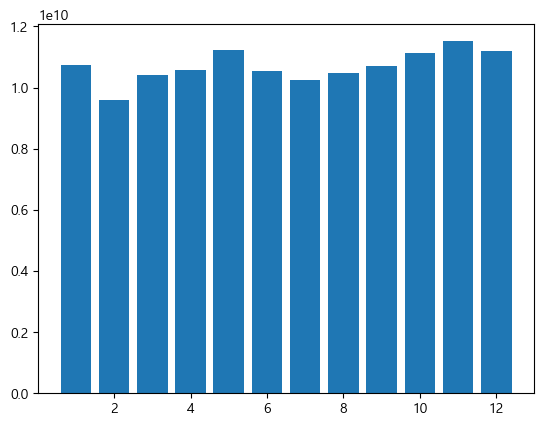

In [157]:
plt.bar(month_df.index, month_df['이용 금액'])
plt.show()

<Axes: xlabel='기준월'>

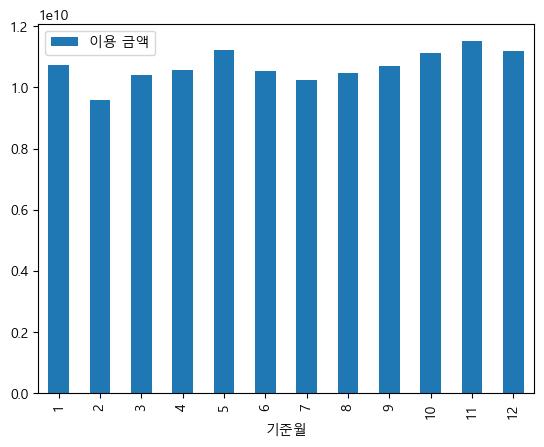

In [158]:
month_df.plot(kind='bar')

<Axes: xlabel='기준월'>

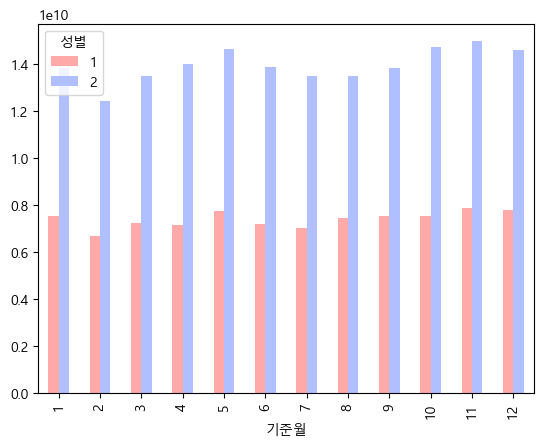

In [159]:
# 월별, 성별을 기준으로 이용 금액의 평균을 그래프로 표시
pd.pivot_table(
    offline,
    index = '기준월',
    columns = '성별',
    values = '이용 금액',
    aggfunc = 'mean'
).plot(kind='bar', color=("#ffa9a9", "#b0bfff"))

<Axes: xlabel='기준년월'>

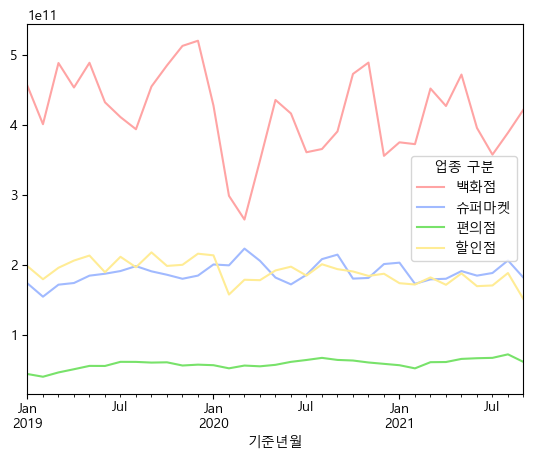

In [160]:
# 기준년월별 업종별로 이용 금액의 합계를 그래프로 표시

pd.pivot_table(
    offline,
    index = '기준년월',
    columns = '업종 구분',
    values = '이용 금액',
    aggfunc = 'sum'
).plot(color=("#FFA4A4", "#A1BAFF", "#78E26A", "#FFEC95"))

In [161]:
group_data = offline[['기준년월', '업종 구분', '이용 금액']].groupby(['기준년월', '업종 구분']).sum()

<Axes: xlabel='기준년월,업종 구분'>

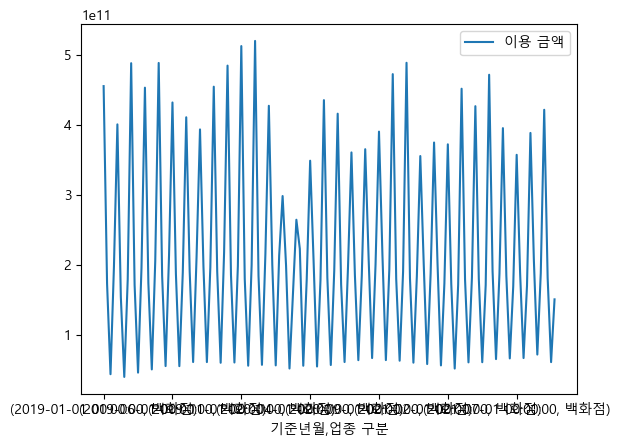

In [162]:
group_data.plot()

<Axes: xlabel='기준년월'>

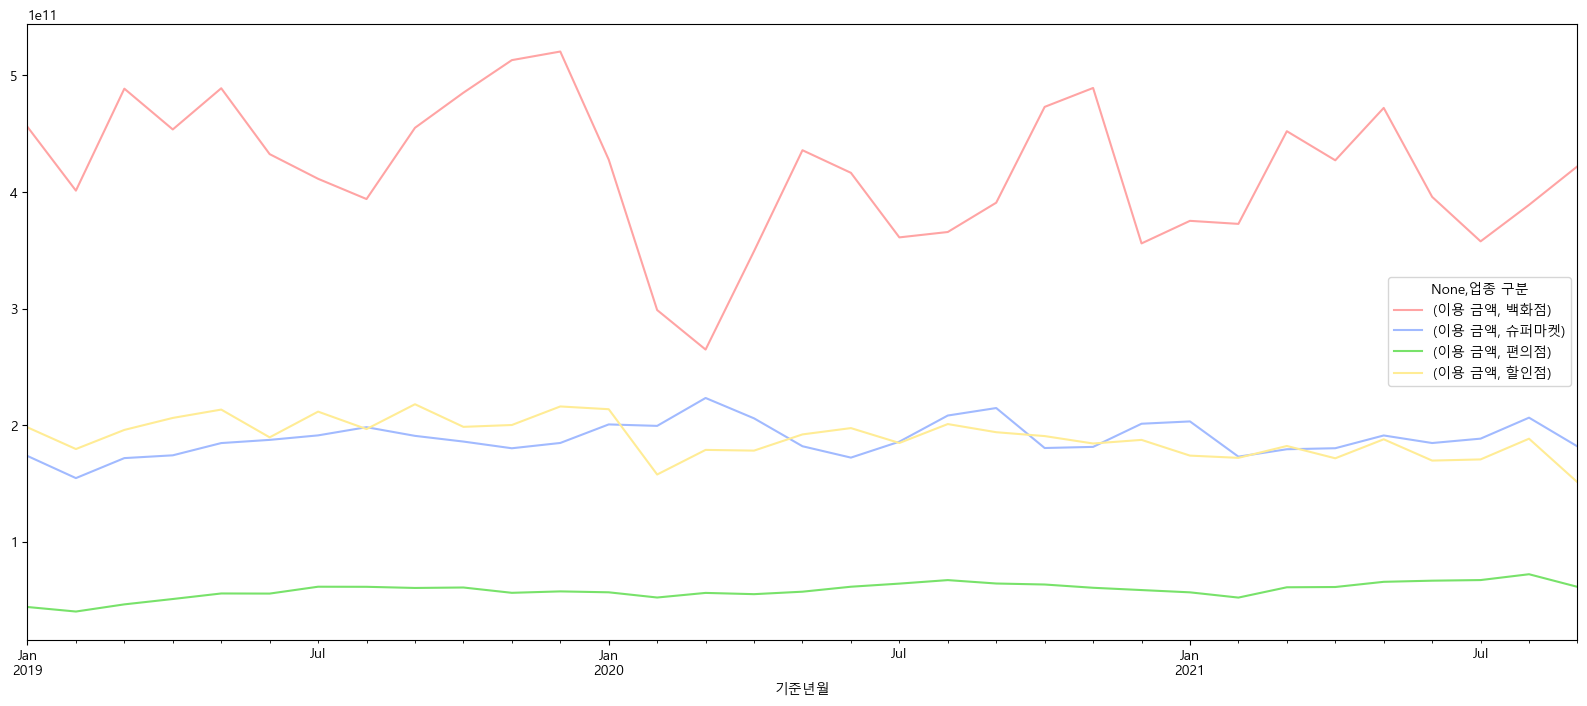

In [163]:
group_data.unstack().plot(figsize=(20,8),color=("#FFA4A4", "#A1BAFF", "#78E26A", "#FFEC95"))

In [164]:
# 연령대 데이터 확인
offline['연령대'].value_counts()

연령대
10    264
20    264
30    264
40    264
50    264
60    264
70    264
80    264
90    264
0     233
1      39
Name: count, dtype: int64

In [165]:
# 파생 변수 → 성별 건당 이용금액의 차이가 존재?

offline['건당이용금액'] = offline['이용 금액']/offline['이용 건수']

<Axes: xlabel='성별'>

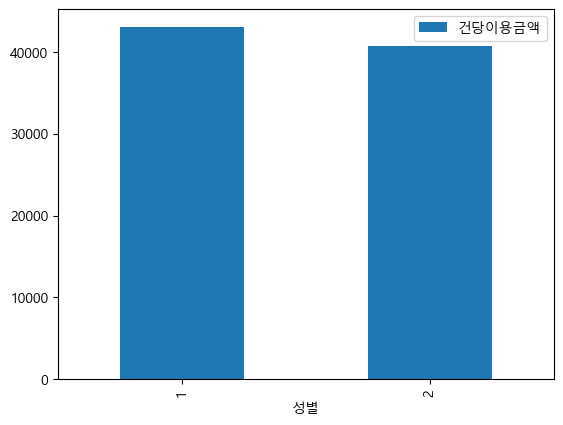

In [166]:
pd.pivot_table(
    offline,
    index = '성별',
    values = '건당이용금액',
    aggfunc = 'mean'
).plot(kind='bar')

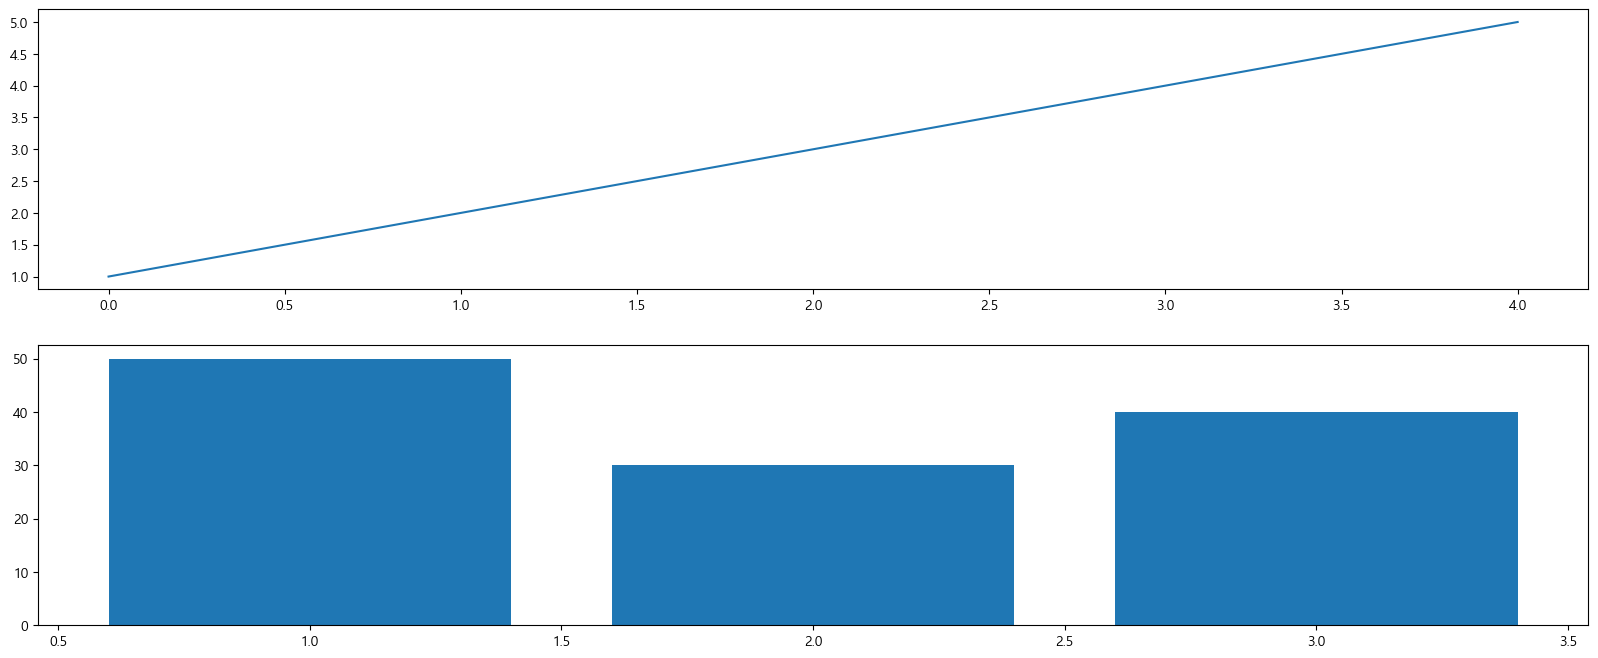

In [167]:
# matplot에서 여러 개의 그래프를 그릴 때
plt.figure(figsize=(20, 8))
plt.subplot(2, 1, 1)
plt.plot([1,2,3,4,5])
plt.subplot(2, 1, 2)
plt.bar([1,2,3], [50,30,40])
plt.show()

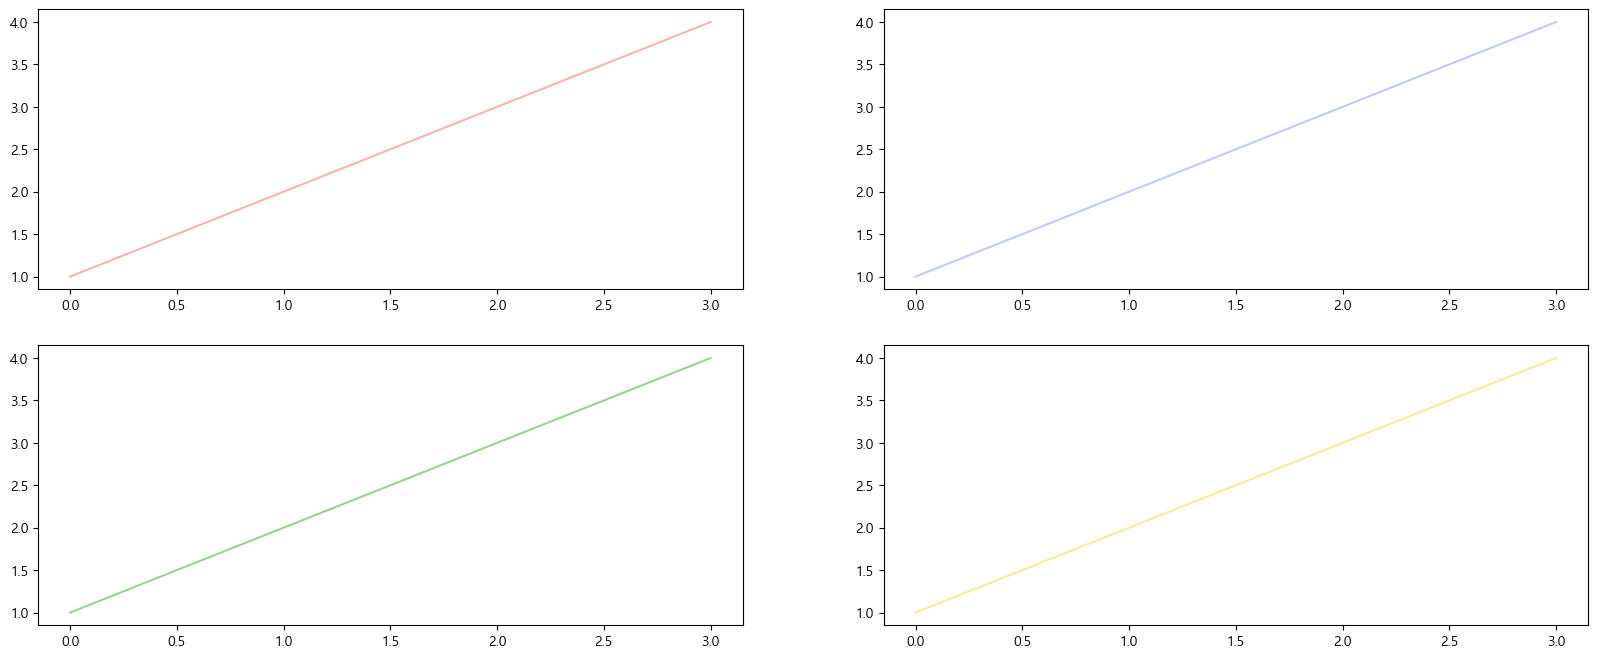

In [ ]:
# subplots() → 영역을 나눠주는 함수 → 영역을 나눈 캔버스를 생성
    # → 앞에서 생성한 캔버스의 크기는 초기화하고 새로 생성
    # 2개의 데이터를 되돌려준다. // 1. 캔버스, 2. 캔버스 영역
# fig, axes를 왜 쓰나 했더니!!!!!!!!!!!!!!!! 이래서엿어!!!!!!!!! 대박!!!!!!!!!!!
# 아니 헐 그래서 매번 axes 로 한 거였구나 대박 이거였구나
# 그냥 주구장창 axes[0], axes[1] 이랬었는ㄴ데,,,

fig, axes = plt.subplots(2, 2, figsize=(20,8))
axes[0][0].plot([1,2,3,4], color="#FFB2B2")
axes[0][1].plot([1,2,3,4], color="#C0CBFF")
axes[1][0].plot([1,2,3,4], color="#97D48F")
axes[1][1].plot([1,2,3,4], color="#FFE89E")


<Axes: xlabel='기준년월'>

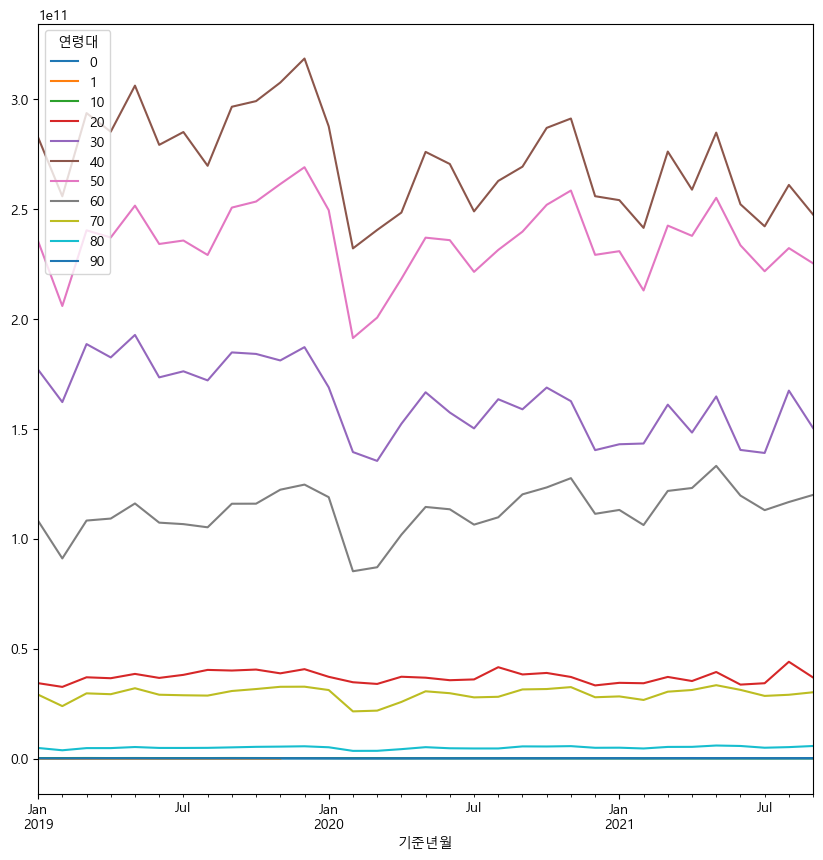

In [169]:
# 연령대 별로 그래프를 따로 생성
group_data2 = pd.pivot_table(
    offline,
    index = '기준년월',
    columns = '연령대',
    values = '이용 금액',
    aggfunc = 'sum'
)

group_data2.plot(figsize=(10,10))

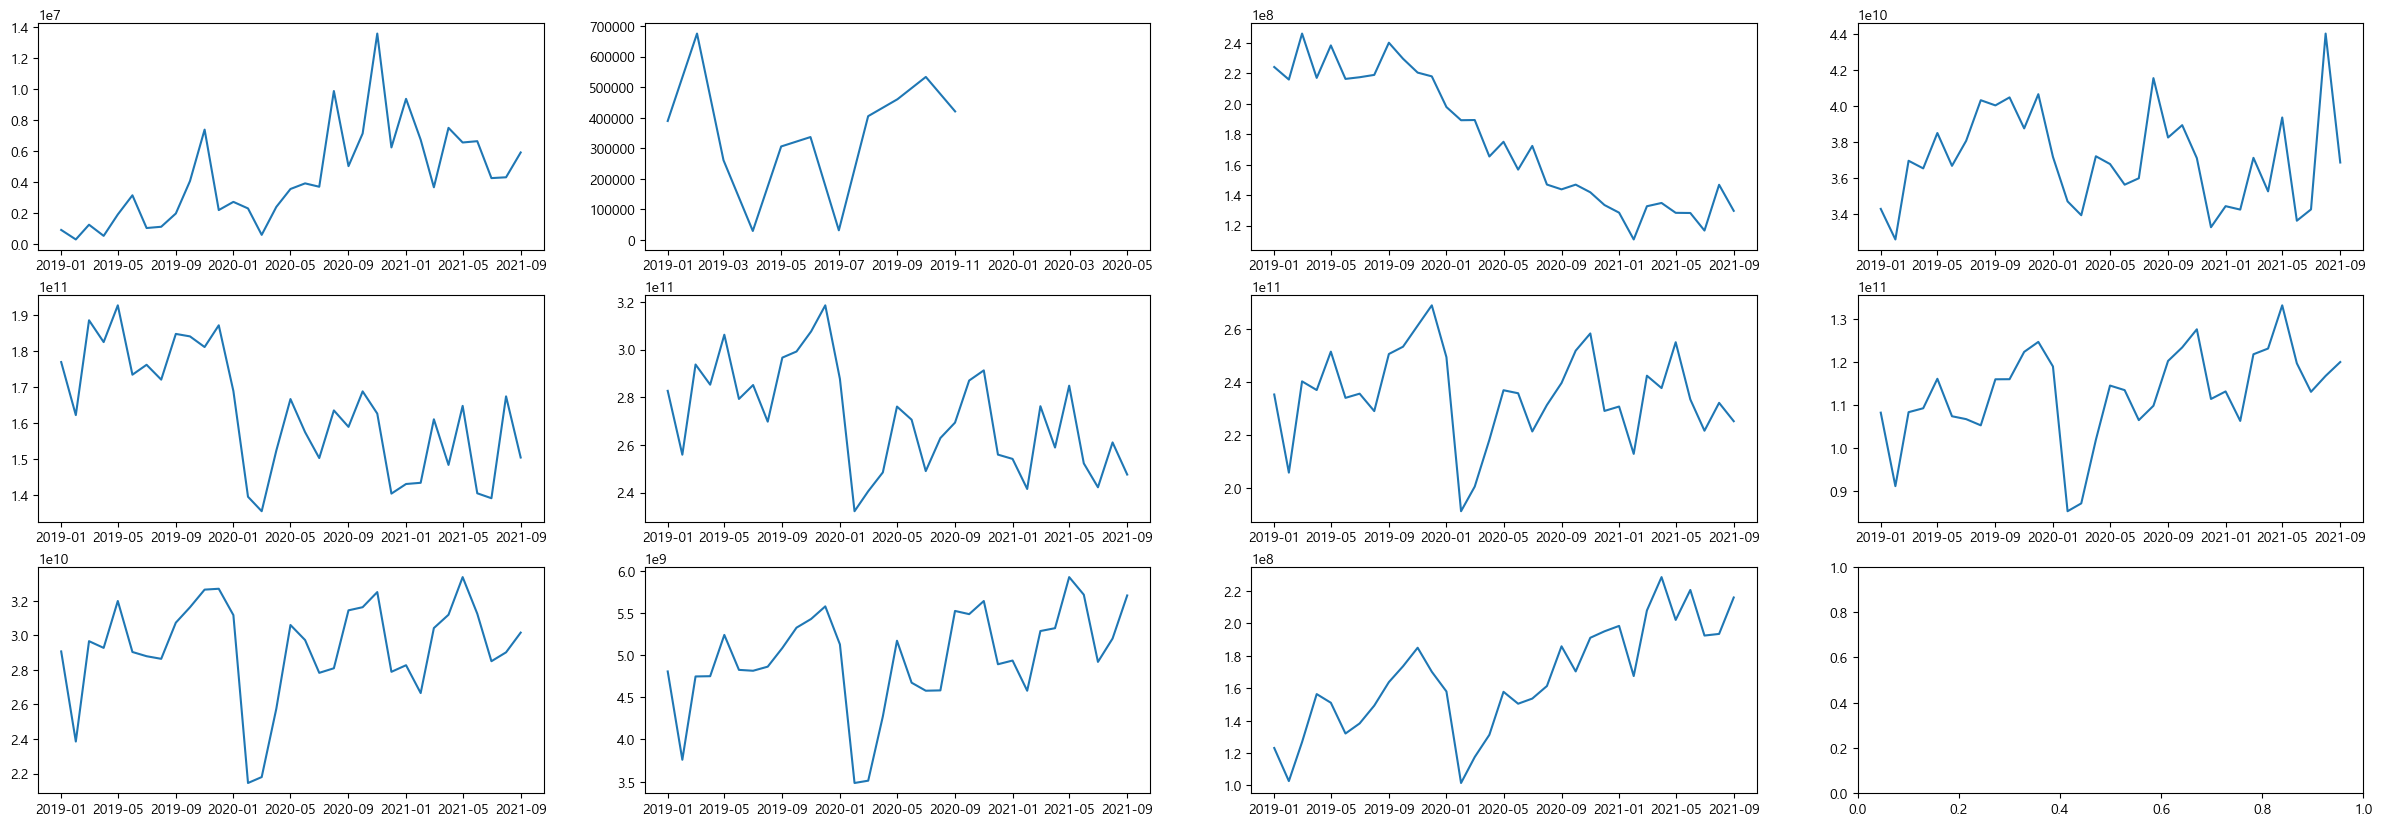

In [170]:
fig, axes = plt.subplots(3, 4, figsize=(30,10))

for i in range(len(group_data2.columns)):
    # row 조건: 4로 나눈 몫
    row = i // 4
    # col 조건: 4로 나눈 나머지
    cols = i % 4
    axes[row][cols].plot(group_data2.iloc[:, i])

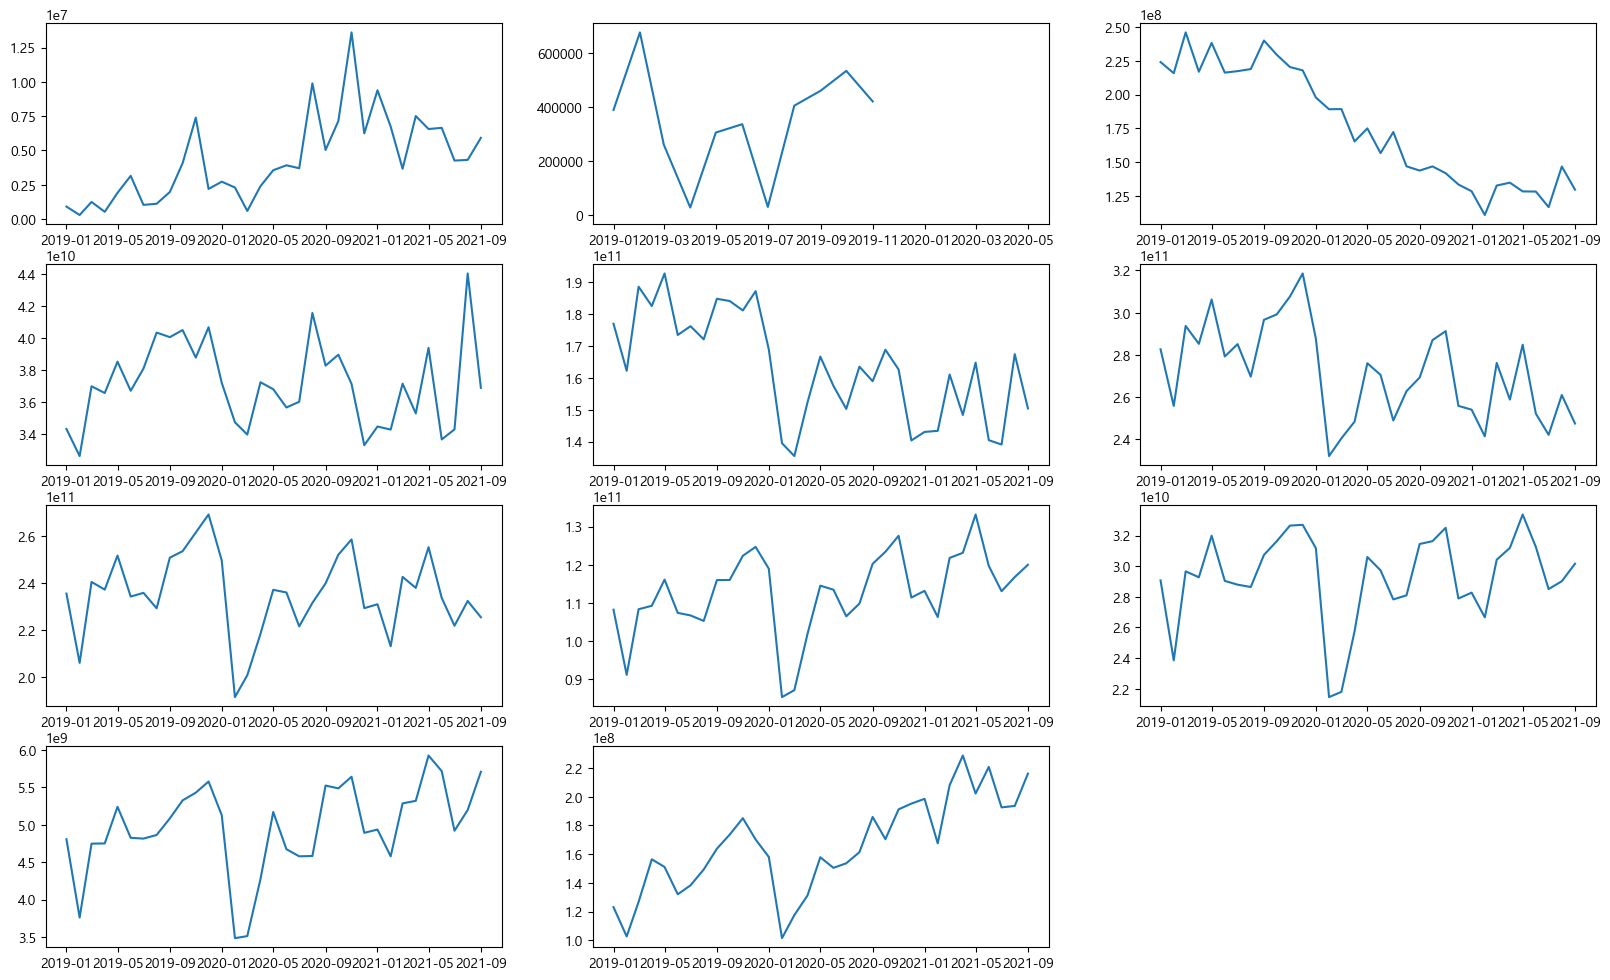

In [171]:
# 행을 4개로 열을 3개로 해서 subplot() 이용
# subplot(row, cols, position): position은 좌에서 우로, 위에서 아래로

# 캔버스 사이즈 지정
plt.figure(figsize=(20, 12))
for i in range(len(group_data2.columns)):
    # i는 0부터 10까지
    plt.subplot(4, 3, i+1)
    plt.plot(group_data2.iloc[:,i])

plt.show()

### 연습문제
1. offline 데이터에서 업종, 성별 별로 총 이용금액의 합계를 라인 그래프로 표시
    - 8개 데이터를 각각 그래프로 생성
    - subplot(), subplots()를 이용해서 하나의 캔버스에 그래프를 생성
    - 행 4, 열 2

In [172]:
group_data3 = pd.pivot_table(
    offline,
    index = '업종 구분',
    columns = '성별',
    values = '이용 금액',
    aggfunc = 'sum'
)

group_data3

성별,1,2
업종 구분,,
백화점,3.937261e+12,9.855847e+12
슈퍼마켓,2.356114e+12,3.865891e+12
편의점,1.060329e+12,8.714579e+11
할인점,2.309021e+12,3.942937e+12


In [173]:
# groupby() 함수를 이용하기 전에 컬럼을 필터링하고 그룹화 진행
# 이번에는 그룹핑을 진행하고 연산을 하기 전에 컬럼을 필터링

group_data3 = offline.groupby(['기준년월', '성별', '업종 구분'])['이용 금액'].sum()

In [174]:
# group_data3 = offline.groupby(['기준년월', '성별', '업종 구분'])[['이용 금액']].sum()

In [175]:
group_data3.unstack()

업종 구분                   백화점          슈퍼마켓           편의점           할인점
기준년월       성별                                                        
2019-01-01 1   1.243582e+11  6.315280e+10  2.337134e+10  7.167173e+10
           2   3.315373e+11  1.104603e+11  2.071225e+10  1.265001e+11
2019-02-01 1   1.105301e+11  5.722725e+10  2.134192e+10  6.524339e+10
           2   2.906615e+11  9.741180e+10  1.885490e+10  1.143270e+11
2019-03-01 1   1.326044e+11  6.287926e+10  2.490085e+10  6.927964e+10
...                     ...           ...           ...           ...
2021-07-01 2   2.510756e+11  1.158746e+11  2.976415e+10  1.066457e+11
2021-08-01 1   1.235541e+11  7.952493e+10  4.012404e+10  7.300243e+10
           2   2.654136e+11  1.269435e+11  3.206470e+10  1.154271e+11
2021-09-01 1   1.283211e+11  7.045715e+10  3.476593e+10  5.703062e+10
           2   2.937602e+11  1.113523e+11  2.659689e+10  9.404897e+10

[66 rows x 4 columns]

In [176]:
group_data3 = group_data3.unstack().unstack()

In [177]:
group_data4 = offline[['기준년월', '성별', '업종 구분', '이용 금액']].groupby(['기준년월', '성별', '업종 구분']).sum()

In [178]:
group_data4.unstack()

이용 금액                                          
업종 구분                   백화점          슈퍼마켓           편의점           할인점
기준년월       성별                                                        
2019-01-01 1   1.243582e+11  6.315280e+10  2.337134e+10  7.167173e+10
           2   3.315373e+11  1.104603e+11  2.071225e+10  1.265001e+11
2019-02-01 1   1.105301e+11  5.722725e+10  2.134192e+10  6.524339e+10
           2   2.906615e+11  9.741180e+10  1.885490e+10  1.143270e+11
2019-03-01 1   1.326044e+11  6.287926e+10  2.490085e+10  6.927964e+10
...                     ...           ...           ...           ...
2021-07-01 2   2.510756e+11  1.158746e+11  2.976415e+10  1.066457e+11
2021-08-01 1   1.235541e+11  7.952493e+10  4.012404e+10  7.300243e+10
           2   2.654136e+11  1.269435e+11  3.206470e+10  1.154271e+11
2021-09-01 1   1.283211e+11  7.045715e+10  3.476593e+10  5.703062e+10
           2   2.937602e+11  1.113523e+11  2.659689e+10  9.404897e+10

[66 rows x 4 columns]

In [179]:
group_data3.iloc[:, 0]

기준년월
2019-01-01    1.243582e+11
2019-02-01    1.105301e+11
2019-03-01    1.326044e+11
2019-04-01    1.259369e+11
2019-05-01    1.340792e+11
2019-06-01    1.190628e+11
2019-07-01    1.134018e+11
2019-08-01    1.089727e+11
2019-09-01    1.265471e+11
2019-10-01    1.352275e+11
2019-11-01    1.432718e+11
2019-12-01    1.476660e+11
2020-01-01    1.215868e+11
2020-02-01    8.443177e+10
2020-03-01    7.669288e+10
2020-04-01    1.004527e+11
2020-05-01    1.236489e+11
2020-06-01    1.175369e+11
2020-07-01    1.013608e+11
2020-08-01    1.064368e+11
2020-09-01    1.137736e+11
2020-10-01    1.360356e+11
2020-11-01    1.417310e+11
2020-12-01    1.063057e+11
2021-01-01    1.119112e+11
2021-02-01    1.109798e+11
2021-03-01    1.309254e+11
2021-04-01    1.230141e+11
2021-05-01    1.384557e+11
2021-06-01    1.118231e+11
2021-07-01    1.066251e+11
2021-08-01    1.235541e+11
2021-09-01    1.283211e+11
Name: (백화점, 1), dtype: float64

subplot

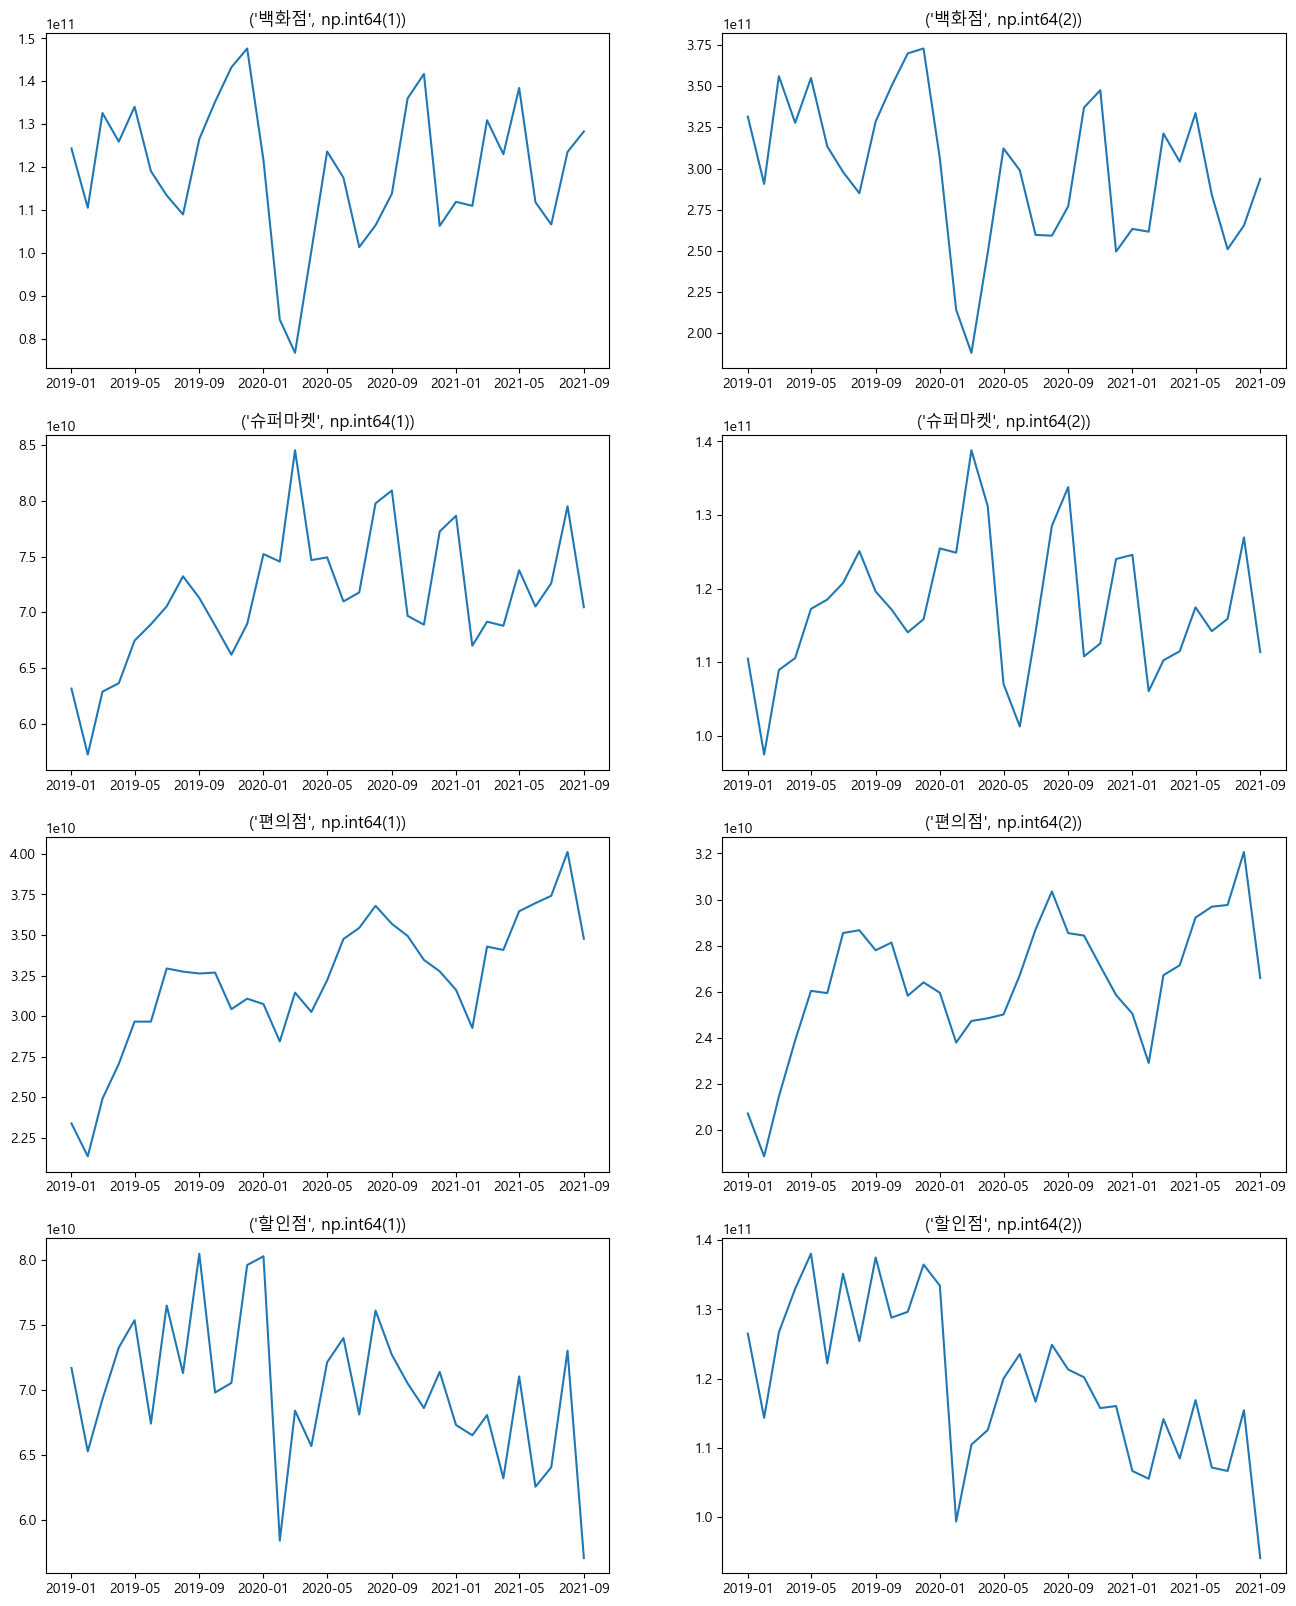

In [180]:
plt.figure(figsize=(16, 20))

for i in range(len(group_data3.columns)):
    plt.subplot(4, 2, i+1)
    plt.plot(group_data3.iloc[:, i])
    plt.title(group_data3.columns[i])

plt.show()

subplots()

C:\Users\hkssn\AppData\Local\Temp\ipykernel_11280\678112323.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


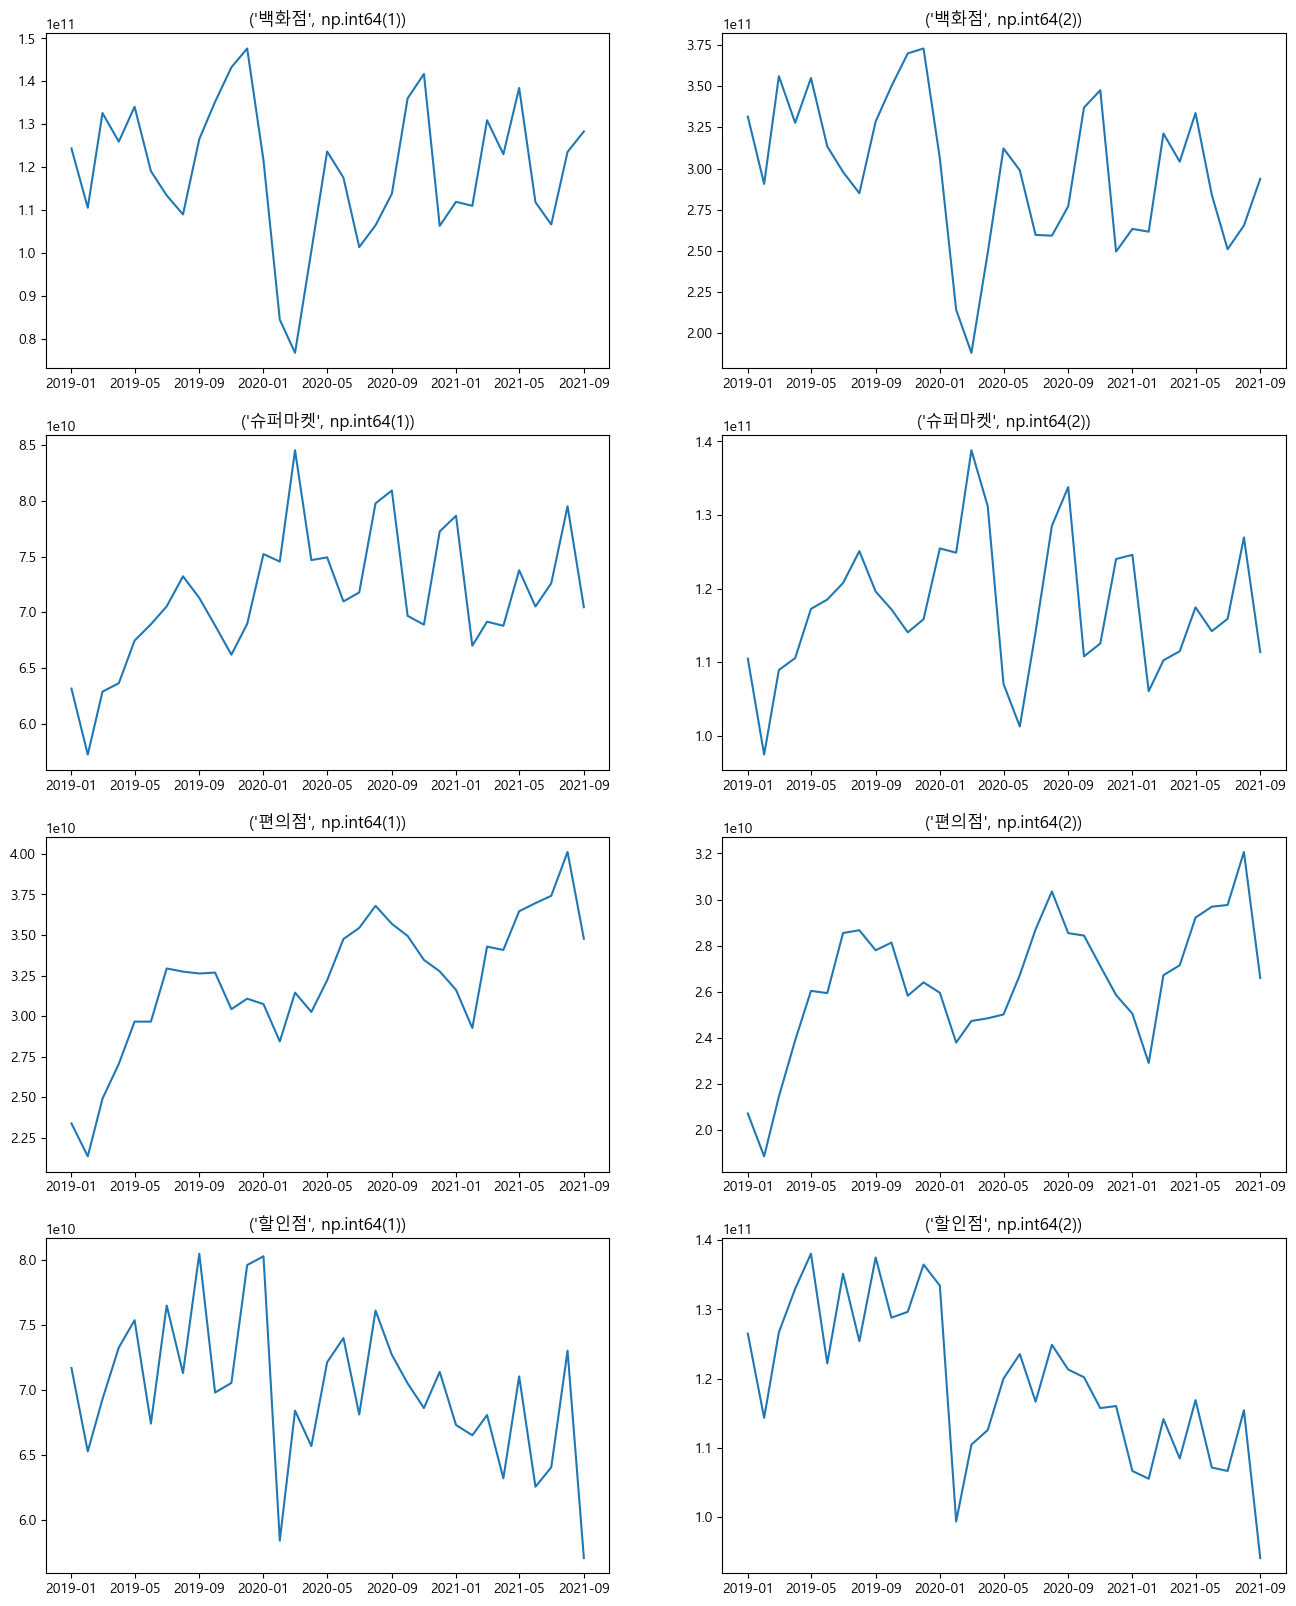

In [181]:
row_num = 4
col_num = 2

fig, axes = plt.subplots(row_num, col_num, figsize=(16, 20))

for i in range(len(group_data3.columns)):
    rows = i // col_num
    cols = i % col_num

    axes[rows][cols].plot(group_data3.iloc[:, i])
    axes[rows][cols].set_title(group_data3.columns[i])

# fig.savefig()
fig.show()

### 오프라인, 온라인 데이터 로드
- 데이터 확인
- 데이터 프레임 결합(유니언, 조인)

In [182]:
offline = pd.read_csv('../csv/card/오프라인.csv', encoding='cp949')
online = pd.read_csv('../csv/card/온라인.csv', encoding='cp949')

In [183]:
offline.info()

<class 'pandas.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   crym          2648 non-null   int64  
 1   tco_btc_nm    2648 non-null   str    
 2   ma_fem_dc     2648 non-null   int64  
 3   agegrp_dc     2648 non-null   int64  
 4   tco_btc_u_ct  2648 non-null   int64  
 5   tco_btc_u_am  2648 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 124.3 KB


In [184]:
online.info()

<class 'pandas.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   crym          651 non-null    int64
 1   ma_fem_dc     651 non-null    int64
 2   agegrp_dc     651 non-null    int64
 3   tco_btc_u_ct  651 non-null    int64
 4   tco_btc_u_am  651 non-null    int64
dtypes: int64(5)
memory usage: 25.6 KB


In [185]:
online['ma_fem_dc'].value_counts()

ma_fem_dc
1    326
2    325
Name: count, dtype: int64

In [186]:
# 두개의 데이터프레임의 이름을 변경
offline.columns = ['기준년월', '업종', '성별', '연령대', '이용건수', '이용금액']
online.columns = ['기준년월', '성별', '연령대', '이용건수', '이용금액']

In [187]:
df = pd.concat( [offline, online], axis = 0, ignore_index = True )

In [188]:
# df 업종 column의 결측치 대체
df['업종'] = df['업종'].fillna('온라인')

In [189]:
# 기준연월 시계열로 변경
df['기준년월'] = pd.to_datetime(df['기준년월'], format='%Y%m')

<Axes: xlabel='기준년월'>

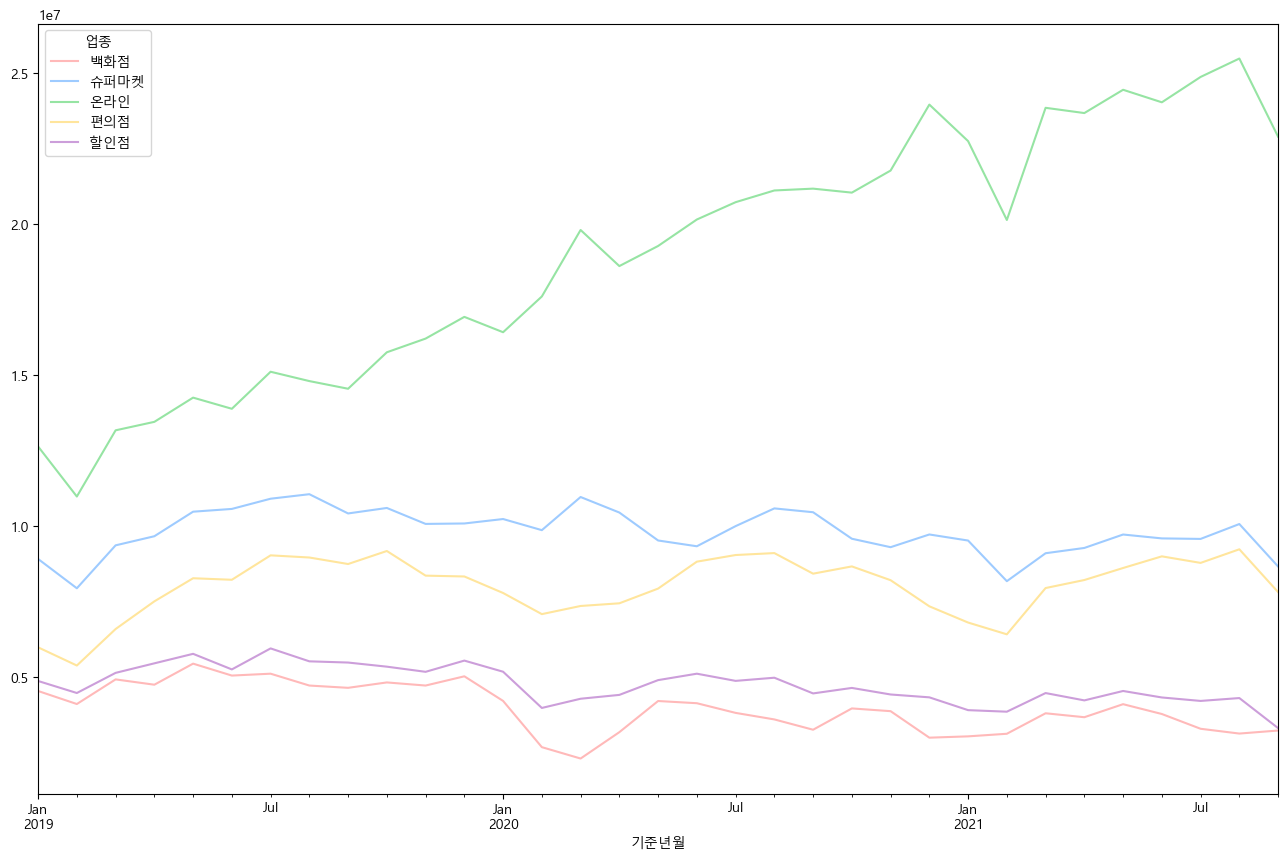

In [190]:
# 모든 업종별로 이용건수 차이를 그래프로 확인
pd.pivot_table(
    df,
    index = '기준년월',
    columns = '업종',
    values = '이용건수',
    aggfunc = 'sum'
).plot(figsize=(16,10), color=("#FFB9B9", "#9ECBFF", "#96E4A3", "#FFE59C", "#CC9EDA"))

<Axes: xlabel='기준년월'>

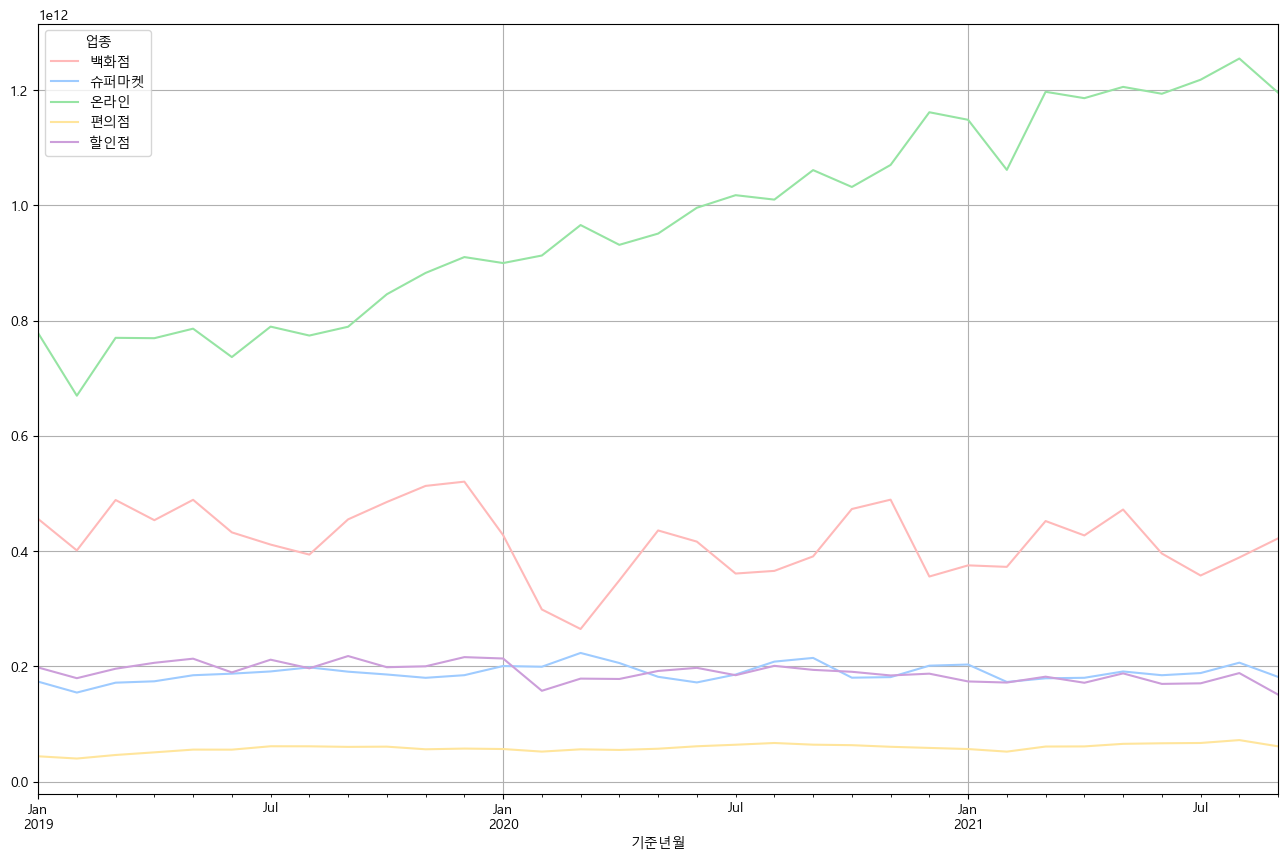

In [192]:
pd.pivot_table(
    df,
    index = '기준년월',
    columns = '업종',
    values = '이용금액',
    aggfunc = 'sum'
).plot(
    figsize=(16,10),
    color=("#FFB9B9", "#9ECBFF", "#96E4A3", "#FFE59C", "#CC9EDA"),
    grid=True
    )

#### 연습문제

- 온라인 / 오프라인을 기준으로 기준년월 총이용금액의 합계를 그래프로 표시

In [205]:
df2 = df[['기준년월', '업종', '이용금액']].groupby(['기준년월', '업종']).sum()

In [ ]:
df2 = df2.unstack()
df2

# df2 = df2['이용금액']
# 이렇게 하면 밑에 줄에 이용금액 일일이 넣지 않아도 됨

In [ ]:
df2['오프라인'] = df2['이용금액']['백화점']+df2['이용금액']['슈퍼마켓']+df2['이용금액']['편의점']+df2['이용금액']['할인점']
df2

# 온라인 제외하고 모두 더하기
# df['오프라인'] = df2.drop('온라인', axis=1).sum(axis=1)

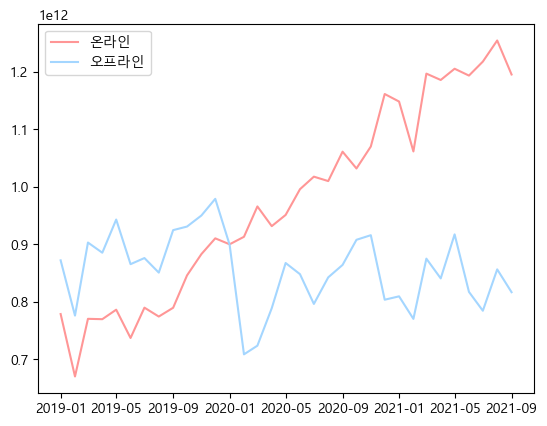

In [ ]:
plt.plot(df2.index, df2['이용금액']['온라인'], label='온라인', color="#FF9696")
plt.plot(df2.index, df2['오프라인'], label='오프라인', color="#A4D6FF")
plt.legend()
plt.show()

강사님 풀이

In [ ]:
online_idx = []
offline_idx = []

for i in range(len(df)):
    if df.loc[i, '업종'] == '온라인':
        online_idx.append(i)
    else:
        offline_idx.append(i)

online_idx

In [214]:
online_df = df.loc[online_idx,]

In [215]:
offline_df = df.loc[offline_idx,]

In [216]:
online_group = online_df.groupby('기준년월')['이용금액'].sum()
offline_group = offline_df.groupby('기준년월')['이용금액'].sum()

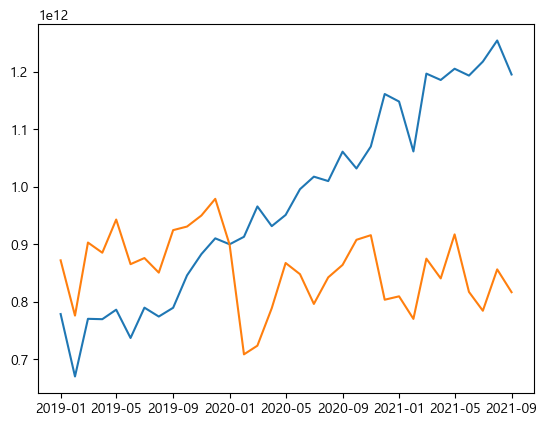

In [218]:
plt.plot(online_group)
plt.plot(offline_group)
plt.show()

In [221]:
# 파생변수 생성 → on/off → 온라인 1, 오프라인 1
# 업종 컬럼을 선택해서 map() 함수 이용, 온라인인지 판단 → int() 변환해서 새로운 컬럼에 대입

df['on/off'] = df['업종'].map(
    lambda x : 'on' if x == '온라인' else 'off'
)

<Axes: xlabel='기준년월'>

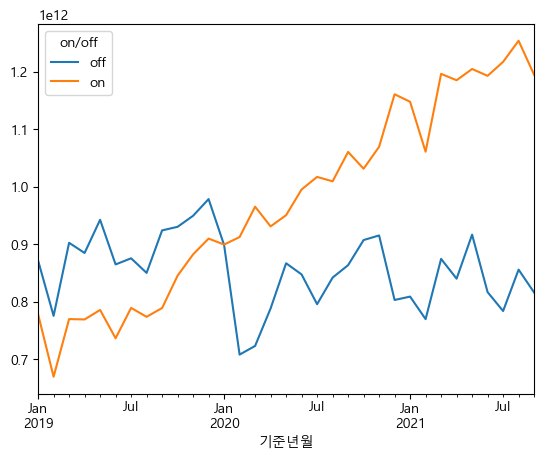

In [222]:
pd.pivot_table(
    df,
    index = '기준년월',
    columns= 'on/off',
    values= '이용금액',
    aggfunc= 'sum'
).plot()

<Axes: xlabel='기준년월'>

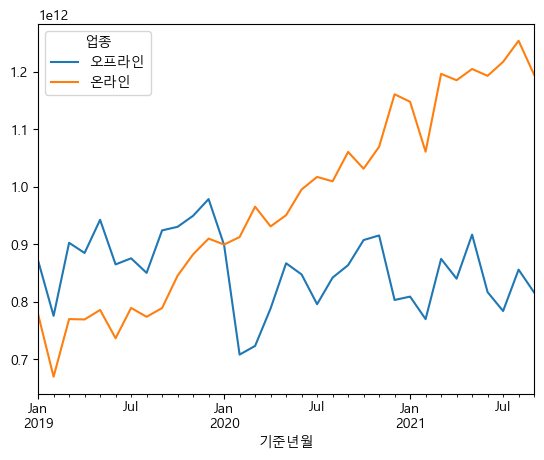

In [227]:
# 수강생분 풀이
pd.pivot_table(
    df,
    index = '기준년월',
    columns = [df['업종'] == '온라인'],
    values = '이용금액',
    aggfunc = 'sum'
).rename(columns = {
    False : '오프라인',
    True : '온라인'
}).plot()

#### 다시 돌아와서